In [1]:
# Import libraries. You may or may not use all of these.
!pip install -q git+https://github.com/tensorflow/docs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

import tensorflow_docs as tfdocs
import tensorflow_docs.plots
import tensorflow_docs.modeling


[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import data
## !wget https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
dataset = pd.read_csv('insurance.csv')
dataset.tail()

,age,sex,bmi,children,smoker,region,expenses
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95
1337,61,female,29.1,0,yes,northwest,29141.36


In [3]:
dataset.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
# convert sex column into numerical
dataset["sex"] = dataset["sex"].map({
    "male": 0,
    "female": 1
})
# convert smoker column into numerical
dataset["smoker"] = dataset["smoker"].map({
    "no": 0,
    "yes": 1
})

In [6]:
# convert region column into numerical
dataset = pd.get_dummies(
    dataset,
    columns=["region"]
)

In [7]:
# convert boolean datatype to integer
region_cols = [
    "region_northeast",
    "region_northwest",
    "region_southeast",
    "region_southwest"
]

dataset[region_cols] = dataset[region_cols].astype(int)

In [8]:
# train test split
from sklearn.model_selection import train_test_split

train_dataset, test_dataset = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42

)

In [9]:
# create labels
train_labels = train_dataset.pop("expenses")
test_labels = test_dataset.pop("expenses")

In [10]:
# build model
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [11]:
model.compile(
    optimizer='adam',
    loss='mae',
    metrics=['mae', 'mse']
)

In [12]:
history = model.fit(
    train_dataset,
    train_labels,
    epochs=100,
    validation_split=0.2
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 13498.1143 - mae: 13498.1143 - mse: 324866432.0000 - val_loss: 12609.0479 - val_mae: 12609.0479 - val_mse: 309088800.0000
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13437.0898 - mae: 13437.0898 - mse: 323163936.0000 - val_loss: 12528.1836 - val_mae: 12528.1836 - val_mse: 306880736.0000
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13319.4561 - mae: 13319.4561 - mse: 319866336.0000 - val_loss: 12363.2559 - val_mae: 12363.2559 - val_mse: 302420000.0000
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13088.4785 - mae: 13088.4785 - mse: 313436736.0000 - val_loss: 12054.6064 - val_mae: 12054.6064 - val_mse: 294228576.0000
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12680.0635 - mae: 12680.0635 - mse: 302296672.0000 - val_loss: 11534.8223 - val_mae: 11534.8223 - val_mse: 280880800.0000
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12022.9766 - mae: 12022.9766 - mse: 

In [13]:
loss, mae, mse = model.evaluate(test_dataset, test_labels, verbose=2)

print(mae)

9/9 - 0s - 3ms/step - loss: 6295.7329 - mae: 6295.7329 - mse: 157197328.0000
6295.73291015625


9/9 - 0s - 5ms/step - loss: 6295.7329 - mae: 6295.7329 - mse: 157197328.0000
Testing set Mean Abs Error: 6295.73 expenses
The Mean Abs Error must be less than 3500. Keep trying.
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


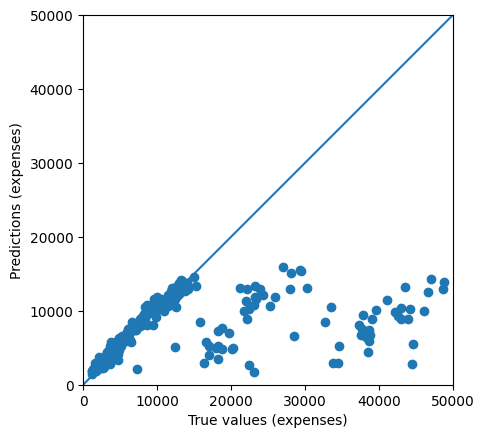

In [14]:
# RUN THIS CELL TO TEST YOUR MODEL. DO NOT MODIFY CONTENTS.
# Test model by checking how well the model generalizes using the test set.
loss, mae, mse = model.evaluate(test_dataset, test_labels, verbose=2)

print("Testing set Mean Abs Error: {:5.2f} expenses".format(mae))

if mae < 3500:
  print("You passed the challenge. Great job!")
else:
  print("The Mean Abs Error must be less than 3500. Keep trying.")

# Plot predictions.
test_predictions = model.predict(test_dataset).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True values (expenses)')
plt.ylabel('Predictions (expenses)')
lims = [0, 50000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims,lims)